# Salary Prediction using Ridge Regression

This project builds a machine learning model that predicts an individual's salary based on demographic and career-related features.

The model uses **Ridge Regression with cross-validated regularization** to reduce overfitting and improve generalization.

The workflow includes:
- Data cleaning
- Feature encoding
- Train/test split
- Feature scaling
- Regularized regression
- Model evaluation using RMSE
- Feature interpretation and visualization
- Predicting salary for new user inputs

The final model achieves a RMSE of approximately $15,000. This means that the predictions typically fall within about ±15k of the actual salaries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load Dataset

The dataset contains information about individuals and their salaries.

Features include:
- Age
- Years of Experience
- Gender
- Education Level
- Job Title
- Salary (target variable)

The goal of this project is to predict **Salary** using the other features.

In [22]:

df = pd.read_csv("Salary Data.csv")
print(df)

      Age  Gender Education Level                      Job Title  \
0    32.0    Male      Bachelor's              Software Engineer   
1    28.0  Female        Master's                   Data Analyst   
2    45.0    Male             PhD                 Senior Manager   
3    36.0  Female      Bachelor's                Sales Associate   
4    52.0    Male        Master's                       Director   
..    ...     ...             ...                            ...   
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  
2                   15.0  150000.0  
3                    7.0   60000.0 

## Data Cleaning and Feature Selection

Before training the model, the dataset is cleaned:

- Rows with missing values are removed.
- The **Job Title** feature is dropped because it creates a large number of dummy variables and leads to overfitting.
- The **Salary** column is separated as the target variable.

Categorical variables (Gender and Education Level) are converted into numerical features using **one-hot encoding**.

The dataset contains a relatively small number of samples (~370 rows).
The Job Title feature was removed because it introduced a very large number of one-hot encoded variables, which led to severe overfitting.

While job title is likely a meaningful predictor of salary, keeping it in this small dataset produced hundreds of sparse features with very few observations each. Dropping it sacrifices some information but results in a more stable model that generalizes better.

In [17]:

df = df.dropna()
y = df["Salary"]
X = df.drop(["Salary", "Job Title"], axis = 1)

X_train_encoded = pd.get_dummies(X, drop_first= True)
print(X_train_encoded.head())
print(X_train_encoded.shape)

    Age  Years of Experience  Gender_Male  Education Level_Master's  \
0  32.0                  5.0         True                     False   
1  28.0                  3.0        False                      True   
2  45.0                 15.0         True                     False   
3  36.0                  7.0        False                     False   
4  52.0                 20.0         True                      True   

   Education Level_PhD  
0                False  
1                False  
2                 True  
3                False  
4                False  
(373, 5)


## Train/Test Split

The dataset is split into training and testing sets.

The training set is used to train the model, while the test set is held out and used only for evaluating the model's ability to generalize to unseen data.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(
    X_train_encoded,
    y,
    test_size = 0.2,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(298, 5)
(75, 5)
(298,)
(75,)


## Feature Scaling

Feature scaling is applied using **StandardScaler**.

This standardizes the features so that they have:
- mean = 0
- standard deviation = 1

Scaling is important for **Ridge Regression** because regularization penalizes large coefficients, and features with larger numeric ranges could otherwise dominate the model.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_encoded.isna().sum()

,0
Age,0
Years of Experience,0
Gender_Male,0
Education Level_Master's,0
Education Level_PhD,0


## Model 2: Ridge Regression with Cross-Validated Alpha

Instead of manually selecting the regularization strength, we can use **cross-validation** to automatically determine the best alpha value.

RidgeCV tests multiple alpha values and selects the one that produces the lowest validation error.

This helps ensure that the model generalizes well to unseen data.

In [14]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas= alphas, cv = 5)

ridge_cv.fit(X_train_scaled, y_train)
print("Best alpha:", ridge_cv.alpha_)

Best alpha: 10.0


## Ridge Regression Model

Ridge Regression is used to control overfitting by applying **L2 regularization**.

The regularization strength is controlled by the parameter **alpha**.

Higher alpha values shrink model coefficients more strongly, helping prevent the model from fitting noise in the data.

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 10.0)
ridge.fit(X_train_scaled, y_train)

y_train_prediction = ridge.predict(X_train_scaled)
y_test_prediction = ridge.predict(X_test_scaled)



## Model Evaluation

Model performance is evaluated using **Root Mean Squared Error (RMSE)**.

RMSE measures the typical difference between predicted salaries and actual salaries.

Lower RMSE values indicate better predictive performance.

In [19]:
from sklearn.metrics import mean_squared_error
import math

train_mse = mean_squared_error(y_train, y_train_prediction)
test_mse = mean_squared_error(y_test, y_test_prediction)

print("Train RMSE:", math.sqrt(train_mse))
print("Test RMSE:", math.sqrt(test_mse))

Train MSE: 15098.669281832741
Test MSE: 14990.800444693064


## Model Interpretation

The learned regression coefficients can be examined to understand how each feature influences the salary prediction.

Larger coefficients indicate stronger influence on the predicted salary.

Because the features were scaled, the coefficients represent **relative influence** rather than direct salary increases.

The model assigns a positive coefficient to the Gender_Male variable, suggesting that male entries in the dataset tend to have slightly higher predicted salaries.

This should not be interpreted as a causal relationship. It simply reflects patterns present in the dataset and may be influenced by sampling bias or other unobserved variables.

In [10]:
import pandas as pd

coefficients = pd.Series(ridge.coef_, index=X_train_encoded.columns)
print(coefficients)

Age                         24681.999329
Years of Experience         13177.572262
Gender_Male                  3817.043674
Education Level_Master's     8898.542115
Education Level_PhD          9223.849487
dtype: float64


## Feature Importance Visualization

The regression coefficients are visualized to better understand which features contribute most to salary predictions.

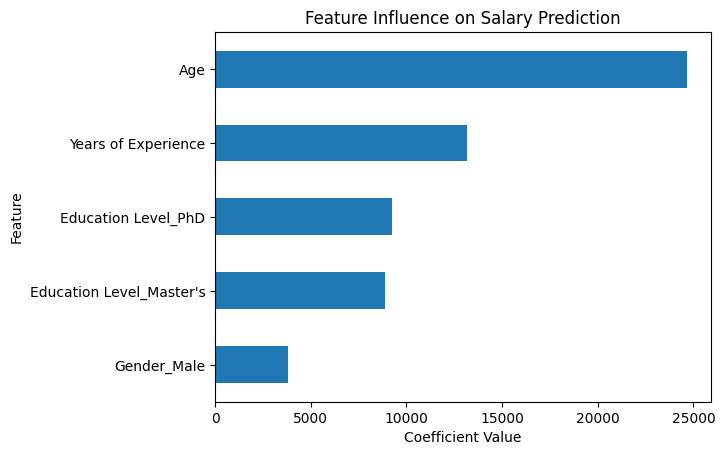

In [11]:
coefficients = coefficients.sort_values()

import matplotlib.pyplot as plt

coefficients.plot(kind="barh")
plt.title("Feature Influence on Salary Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Predicting Salary for New Inputs

To demonstrate how the trained model can be used, the notebook allows a user to enter their own information:

- Age
- Years of Experience
- Gender
- Education Level

The model processes the input using the same preprocessing pipeline and outputs a predicted salary.

Because the model has a test RMSE of about **$15,000**, predictions are presented as a **salary range** rather than a single value.

In [16]:
age = float(input("Age: "))
exp = float(input("Years of Experience: "))
gender = input("Gender (Male/Female): ").strip()
edu = input("Education Level (Bachelor's/Master's/PhD): ").strip()

user_X = pd.DataFrame([{
    "Age": age,
    "Years of Experience": exp,
    "Gender": gender,
    "Education Level": edu
}])

user_encoded = pd.get_dummies(user_X, drop_first=True)

user_encoded = user_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

user_scaled = scaler.transform(user_encoded)

pred = float(ridge_cv.predict(user_scaled)[0])

lo = pred - (math.sqrt(test_mse))
hi = pred + (math.sqrt(test_mse))

print(f"\nPredicted salary: ${pred:,.0f}")
print(f"Typical range:    ${lo:,.0f} – ${hi:,.0f} (± RMSE )")

Age: 35
Years of Experience: 12
Gender (Male/Female): male
Education Level (Bachelor's/Master's/PhD): PhD

Predicted salary: $85,249
Typical range:    $70,096 – $100,402 (± RMSE from held-out test set)


## Conclusion

This project demonstrates a complete machine learning workflow for a regression problem.

Key steps included:

- Data cleaning and preprocessing
- Handling categorical variables with one-hot encoding
- Train/test splitting to measure generalization
- Feature scaling for regularized regression
- Ridge Regression with cross-validation
- Model evaluation using RMSE
- Interpreting and visualizing model coefficients

The final model achieves a **test RMSE of approximately $15,000** meaning predictions are **typically within ±15k of actual salaries**.

This project illustrates how regularized linear models can be applied to real-world datasets to make interpretable predictions.